# Exp6: 基于集成学习的 Amazon 用户评论质量预测

## 一、案例简介

随着电商平台的兴起，以及疫情的持续影响，线上购物在我们的日常生活中扮演着越来越重要的角色。在进行线上商品挑选时，评论往往是我们十分关注的一个方面。然而目前电商网站的评论质量参差不齐，甚至有水军刷好评或者恶意差评的情况出现，严重影响了顾客的购物体验。因此，对于评论质量的预测成为电商平台越来越关注的话题，如果能自动对评论质量进行评估，就能根据预测结果避免展现低质量的评论。本案例中我们将基于集成学习的方法对 Amazon 现实场景中的评论质量进行预测。

## 二、作业说明

本案例中需要大家完成两种集成学习算法的实现（Bagging、AdaBoost.M1），其中基分类器要求使用 SVM 和决策树两种，因此，一共需要对比四组结果（[AUC](https://scikit-learn.org/stable/modules/model_evaluation.html#roc-metrics) 作为评价指标）：

* Bagging + SVM
* Bagging + 决策树
* AdaBoost.M1 + SVM
* AdaBoost.M1 + 决策树

注意集成学习的核心算法需要**手动进行实现**，基分类器可以调库。

### 基本要求
* 根据数据格式设计特征的表示
* 汇报不同组合下得到的 AUC (要求 -- 4种Ensemble model最佳结果AUC>0.7，最差结果AUC>0.55)
* 结合不同集成学习算法的特点分析结果之间的差异
* （使用 sklearn 等第三方库的集成学习算法会酌情扣分）

### 扩展要求
* 尝试其他基分类器（如 k-NN、朴素贝叶斯）
* 分析不同特征的影响
* 分析集成学习算法参数的影响

## 三、数据概览

In [10]:
import pandas as pd
train_df = pd.read_csv('train.csv', sep='\t')

In [12]:
test_df = pd.read_csv('test.csv', sep='\t')

In [13]:
ground_truth = pd.read_csv("groundTruth.csv",sep=',') # 测试集的标签

In [14]:
train_df

,reviewerID,asin,reviewText,overall,votes_up,votes_all,label
0,7885,3901,"First off, allow me to correct a common mistak...",5.0,6,7,0
1,52087,47978,I am really troubled by this Story and Enterta...,3.0,99,134,0
2,5701,3667,A near-perfect film version of a downright glo...,4.0,14,14,1
3,47191,40892,Keep your expectations low. Really really low...,1.0,4,7,0
4,40957,15367,"""they dont make em like this no more...""well.....",5.0,3,6,0
...,...,...,...,...,...,...,...
57034,58315,29374,"If you like beautifully shot, well acted films...",2.0,12,21,0
57035,23328,45548,This is a great set of films Wayne did Fox and...,5.0,15,18,0
57036,27203,42453,It's what's known as a comedy of manners. It's...,3.0,4,5,0
57037,33992,44891,Ellen can do no wrong as far a creating wonder...,5.0,4,5,0


In [16]:
test_df

,Id,reviewerID,asin,reviewText,overall
0,0,82947,37386,I REALLY wanted this series but I am in SHOCK ...,1.0
1,1,10154,23543,I have to say that this is a work of art for m...,4.0
2,2,5789,5724,Alien 3 is certainly the most controversal fil...,3.0
3,3,9198,5909,"I love this film...preachy? Well, of course i...",5.0
4,4,33252,21214,Even though I previously bought the Gamera Dou...,5.0
...,...,...,...,...,...
11203,11203,18250,35309,I honestly never heard of the graphic novel un...,5.0
11204,11204,3200,2130,Archie Bunker's command to stifle YOURSELF! wa...,5.0
11205,11205,37366,41971,"In LSD - My Problem Child, Albert Hoffman wrot...",5.0
11206,11206,1781,33089,I have owned this DVD for over a year now and ...,5.0


In [17]:
ground_truth

,Id,Expected
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
...,...,...
11203,11203,0
11204,11204,0
11205,11205,0
11206,11206,0


In [18]:
ground_truth.Expected.value_counts()

,count
Expected,
0,9064
1,2144


In [19]:
train_df.label.value_counts()

,count
label,
0,44137
1,12902


本次数据来源于 Amazon 电商平台，包含超过 50,000 条用户在购买商品后留下的评论，各列的含义如下：

* reviewerID：用户 ID
* asin：商品 ID
* reviewText：英文评论文本
* overall：用户对商品的打分（1-5）
* votes_up：认为评论有用的点赞数（只在训练集出现）
* votes_all：该评论得到的总评价数（只在训练集出现）
* label：评论质量的 label，1 表示高质量，0 表示低质量（只在训练集出现）

评论质量的 label 来自于其他用户对评论的 votes，votes_up/votes_all ≥ 0.9 的作为高质量评论。此外测试集包含一个额外的列 ID，标识了每一个测试的样例。

**一些tips**：
- 处理文本特征：sklearn.feature_extraction.text.TfidfVectorizer
- 大矩阵的处理：scipy.sparse
- SVM的运算速度较慢：用linearSVC代替SVC
- Ensemble的基类方法最好能输出probability而不是二分类结果，便于提升集成效果：CalibratedClassifierCV

## 四、使用云平台进行实验（选做）

需要用云平台的同学统一联系学堂CC

## 五、数据预处理与特征工程

In [20]:
# 检查数据基本信息、缺失值和重复值

print("训练集形状：", train_df.shape)
print("测试集形状：", test_df.shape)
print("测试集标签形状：", ground_truth.shape)

print("\n训练集各列缺失值数量：")
display(train_df.isnull().sum().to_frame("missing_count"))

print("\n测试集各列缺失值数量：")
display(test_df.isnull().sum().to_frame("missing_count"))

print("\n训练集重复行数量：", train_df.duplicated().sum())
print("测试集重复行数量：", test_df.duplicated().sum())

print("\n训练集各列数据类型：")
display(train_df.dtypes.to_frame("dtype"))

训练集形状： (57039, 7)
测试集形状： (11208, 5)
测试集标签形状： (11208, 2)

训练集各列缺失值数量：


,missing_count
reviewerID,0
asin,0
reviewText,0
overall,0
votes_up,0
votes_all,0
label,0



测试集各列缺失值数量：


,missing_count
Id,0
reviewerID,0
asin,0
reviewText,0
overall,0



训练集重复行数量： 0
测试集重复行数量： 0

训练集各列数据类型：


,dtype
reviewerID,int64
asin,int64
reviewText,object
overall,float64
votes_up,int64
votes_all,int64
label,int64


### 5.1 训练数据与测试数据准备

In [23]:
# 准备模型输入数据和标签

# 文本特征
train_text = train_df["reviewText"].astype(str)
test_text = test_df["reviewText"].astype(str)

# 数值特征：商品评分
train_overall = train_df[["overall"]].astype(float)
test_overall = test_df[["overall"]].astype(float)

# 训练集标签与测试集真实标签
y_train = train_df["label"].astype(int).to_numpy()
y_test = ground_truth["Expected"].astype(int).to_numpy()

# 检查测试集样本与标签是否按照 Id 一一对应
id_aligned = (
    test_df["Id"].to_numpy() == ground_truth["Id"].to_numpy()
).all()

print("训练文本数量：", len(train_text))
print("测试文本数量：", len(test_text))
print("训练标签数量：", len(y_train))
print("测试标签数量：", len(y_test))
print("测试集 Id 与 groundTruth Id 是否完全对应：", id_aligned)

print("\n训练集标签分布：")
print(pd.Series(y_train).value_counts().sort_index())

print("\n测试集标签分布：")
print(pd.Series(y_test).value_counts().sort_index())

训练文本数量： 57039
测试文本数量： 11208
训练标签数量： 57039
测试标签数量： 11208
测试集 Id 与 groundTruth Id 是否完全对应： True

训练集标签分布：
0    44137
1    12902
Name: count, dtype: int64

测试集标签分布：
0    9064
1    2144
Name: count, dtype: int64


### 5.2 文本特征提取（TF-IDF）

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

# TF-IDF 向量化
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    sublinear_tf=True
)

# 使用训练集拟合，再分别转换训练集和测试集
X_train_text = tfidf.fit_transform(train_text)
X_test_text = tfidf.transform(test_text)

# 将 overall 拼接到 TF-IDF 特征后面
X_train = hstack([
    X_train_text,
    csr_matrix(train_overall.values)
])

X_test = hstack([
    X_test_text,
    csr_matrix(test_overall.values)
])

print("TF-IDF词汇表大小：", len(tfidf.vocabulary_))
print("训练集特征矩阵：", X_train.shape)
print("测试集特征矩阵：", X_test.shape)

TF-IDF词汇表大小： 10000
训练集特征矩阵： (57039, 10001)
测试集特征矩阵： (11208, 10001)


## 六、手动实现 Bagging 集成学习算法

In [25]:
import numpy as np
from sklearn.base import clone


class BaggingScratch:
    """
    手动实现的 Bagging 二分类器。

    参数
    ----------
    base_estimator : sklearn 分类器
        基分类器，需要支持 predict_proba()。

    n_estimators : int, default=10
        基分类器数量。

    max_samples : float or int, default=1.0
        每次 Bootstrap 抽样使用的样本数量。
        若为浮点数，表示占训练集的比例；
        若为整数，表示具体样本数。

    random_state : int, default=42
        随机种子。
    """

    def __init__(
        self,
        base_estimator,
        n_estimators=10,
        max_samples=1.0,
        random_state=42
    ):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.max_samples = max_samples
        self.random_state = random_state

        self.estimators_ = []
        self.bootstrap_indices_ = []

    def fit(self, X, y):
        """
        通过有放回抽样生成多个 Bootstrap 数据集，
        并分别训练基分类器。
        """
        X = X.tocsr()
        y = np.asarray(y)

        n_samples = X.shape[0]

        if isinstance(self.max_samples, float):
            sample_size = int(n_samples * self.max_samples)
        else:
            sample_size = int(self.max_samples)

        if sample_size <= 0 or sample_size > n_samples:
            raise ValueError("max_samples 对应的样本数必须在 1 到训练集样本数之间。")

        rng = np.random.default_rng(self.random_state)

        self.estimators_ = []
        self.bootstrap_indices_ = []

        for i in range(self.n_estimators):
            # 有放回地抽取训练样本
            bootstrap_indices = rng.choice(
                n_samples,
                size=sample_size,
                replace=True
            )

            X_bootstrap = X[bootstrap_indices]
            y_bootstrap = y[bootstrap_indices]

            # 克隆一个新的、尚未训练的基分类器
            estimator = clone(self.base_estimator)

            # 在 Bootstrap 样本上训练
            estimator.fit(X_bootstrap, y_bootstrap)

            self.estimators_.append(estimator)
            self.bootstrap_indices_.append(bootstrap_indices)

            print(
                f"Bagging 基分类器 {i + 1}/{self.n_estimators} 训练完成"
            )

        return self

    def predict_proba(self, X):
        """
        对所有基分类器输出的概率取平均。
        """
        if len(self.estimators_) == 0:
            raise ValueError("模型尚未训练，请先调用 fit()。")

        X = X.tocsr()

        probability_sum = np.zeros((X.shape[0], 2), dtype=float)

        for estimator in self.estimators_:
            if not hasattr(estimator, "predict_proba"):
                raise AttributeError(
                    "基分类器必须支持 predict_proba()。"
                )

            probability_sum += estimator.predict_proba(X)

        average_probability = probability_sum / len(self.estimators_)

        return average_probability

    def predict(self, X, threshold=0.5):
        """
        根据正类平均预测概率得到最终类别。
        """
        positive_probability = self.predict_proba(X)[:, 1]

        return (positive_probability >= threshold).astype(int)

### 6.1 Bagging + SVM

In [26]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score
import time

# LinearSVC 本身没有 predict_proba，
# 使用概率校准使其能够输出正类概率
svm_base = CalibratedClassifierCV(
    estimator=LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42
    ),
    method="sigmoid",
    cv=3
)

# 手动实现的 Bagging + SVM
bagging_svm = BaggingScratch(
    base_estimator=svm_base,
    n_estimators=5,
    max_samples=0.8,
    random_state=42
)

start_time = time.time()

bagging_svm.fit(X_train, y_train)

# 获取测试集正类预测概率并计算 AUC
bagging_svm_probability = bagging_svm.predict_proba(X_test)[:, 1]
bagging_svm_auc = roc_auc_score(y_test, bagging_svm_probability)

bagging_svm_time = time.time() - start_time

print("\nBagging + SVM 测试集 AUC：", round(bagging_svm_auc, 4))
print("总运行时间：", round(bagging_svm_time, 2), "秒")

Bagging 基分类器 1/5 训练完成
Bagging 基分类器 2/5 训练完成
Bagging 基分类器 3/5 训练完成
Bagging 基分类器 4/5 训练完成
Bagging 基分类器 5/5 训练完成

Bagging + SVM 测试集 AUC： 0.7909
总运行时间： 37.49 秒


### 6.2 Bagging + Decision Tree

In [27]:
from sklearn.tree import DecisionTreeClassifier

# 决策树基分类器
tree_base = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42
)

# 手动实现 Bagging + Decision Tree
bagging_tree = BaggingScratch(
    base_estimator=tree_base,
    n_estimators=5,
    max_samples=0.8,
    random_state=42
)

start_time = time.time()

bagging_tree.fit(X_train, y_train)

bagging_tree_probability = bagging_tree.predict_proba(X_test)[:, 1]
bagging_tree_auc = roc_auc_score(y_test, bagging_tree_probability)

bagging_tree_time = time.time() - start_time

print("\nBagging + Decision Tree 测试集 AUC：", round(bagging_tree_auc, 4))
print("总运行时间：", round(bagging_tree_time, 2), "秒")

Bagging 基分类器 1/5 训练完成
Bagging 基分类器 2/5 训练完成
Bagging 基分类器 3/5 训练完成
Bagging 基分类器 4/5 训练完成
Bagging 基分类器 5/5 训练完成

Bagging + Decision Tree 测试集 AUC： 0.7619
总运行时间： 58.46 秒


## 七、手动实现 AdaBoost.M1 集成学习算法

In [28]:
import numpy as np
from sklearn.base import clone


class AdaBoostM1Scratch:
    """
    手动实现的 AdaBoost.M1 二分类器。

    参数
    ----------
    base_estimator : sklearn 分类器
        基分类器，必须支持 fit(X, y, sample_weight=...)。

    n_estimators : int, default=10
        最多训练的基分类器数量。

    learning_rate : float, default=1.0
        每个基分类器权重的缩放系数。

    random_state : int, default=42
        随机种子。
    """

    def __init__(
        self,
        base_estimator,
        n_estimators=10,
        learning_rate=1.0,
        random_state=42
    ):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.random_state = random_state

        self.estimators_ = []
        self.estimator_weights_ = []
        self.estimator_errors_ = []

    def fit(self, X, y):
        """
        根据样本分类错误情况迭代更新样本权重，
        并训练多个基分类器。
        """
        X = X.tocsr()
        y = np.asarray(y).astype(int)

        n_samples = X.shape[0]

        # 初始时每个训练样本具有相同权重
        sample_weight = np.full(
            n_samples,
            1.0 / n_samples,
            dtype=float
        )

        self.estimators_ = []
        self.estimator_weights_ = []
        self.estimator_errors_ = []

        for i in range(self.n_estimators):
            estimator = clone(self.base_estimator)

            # 为支持随机种子的基分类器设置不同随机状态
            if hasattr(estimator, "random_state"):
                estimator.set_params(
                    random_state=self.random_state + i
                )

            # 使用当前样本权重训练基分类器
            estimator.fit(
                X,
                y,
                sample_weight=sample_weight
            )

            prediction = estimator.predict(X).astype(int)
            incorrect = prediction != y

            # 计算当前分类器的加权错误率
            error = np.sum(
                sample_weight * incorrect
            ) / np.sum(sample_weight)

            # 防止 log(0) 等数值问题
            error = np.clip(error, 1e-10, 1 - 1e-10)

            # AdaBoost.M1要求分类器优于随机猜测
            if error >= 0.5:
                print(
                    f"第 {i + 1} 个基分类器错误率为 "
                    f"{error:.4f}，不优于随机猜测，停止训练。"
                )
                break

            # 计算当前基分类器在最终集成中的权重
            alpha = (
                self.learning_rate
                * np.log((1.0 - error) / error)
            )

            self.estimators_.append(estimator)
            self.estimator_weights_.append(alpha)
            self.estimator_errors_.append(error)

            # 错分样本权重增大，正确分类样本权重保持不变
            sample_weight *= np.exp(
                alpha * incorrect.astype(float)
            )

            # 权重归一化
            sample_weight /= np.sum(sample_weight)

            print(
                f"AdaBoost 基分类器 {i + 1}/{self.n_estimators} "
                f"训练完成，错误率：{error:.4f}，"
                f"分类器权重：{alpha:.4f}"
            )

            # 若训练误差接近0，则无需继续迭代
            if error <= 1e-10:
                print("当前基分类器已达到近乎完全分类，提前停止。")
                break

        if len(self.estimators_) == 0:
            raise RuntimeError(
                "未能训练出有效的基分类器，请调整基分类器参数。"
            )

        self.estimator_weights_ = np.asarray(
            self.estimator_weights_,
            dtype=float
        )

        return self

    def decision_function(self, X):
        """
        计算所有基分类器的加权投票分数。

        分数越大，样本越可能属于类别1；
        分数越小，样本越可能属于类别0。
        """
        if len(self.estimators_) == 0:
            raise ValueError("模型尚未训练，请先调用 fit()。")

        X = X.tocsr()
        weighted_score = np.zeros(X.shape[0], dtype=float)

        for estimator, alpha in zip(
            self.estimators_,
            self.estimator_weights_
        ):
            prediction = estimator.predict(X).astype(int)

            # 将类别0、1转换为-1、+1
            signed_prediction = 2 * prediction - 1
            weighted_score += alpha * signed_prediction

        return weighted_score

    def predict_proba(self, X):
        """
        将加权投票分数转换为近似概率。
        """
        score = self.decision_function(X)

        # 限制范围，防止指数运算溢出
        score = np.clip(score, -50, 50)

        positive_probability = 1.0 / (
            1.0 + np.exp(-2.0 * score)
        )

        return np.column_stack([
            1.0 - positive_probability,
            positive_probability
        ])

    def predict(self, X):
        """
        根据加权投票分数输出最终类别。
        """
        return (
            self.decision_function(X) >= 0
        ).astype(int)

### 7.1 AdaBoost.M1 + SVM

In [29]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score
import time

# SVM基分类器
svm_base = CalibratedClassifierCV(
    estimator=LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42
    ),
    method="sigmoid",
    cv=3
)

# 手动实现 AdaBoost.M1 + SVM
adaboost_svm = AdaBoostM1Scratch(
    base_estimator=svm_base,
    n_estimators=5,
    learning_rate=1.0,
    random_state=42
)

start_time = time.time()

adaboost_svm.fit(X_train, y_train)

adaboost_svm_probability = adaboost_svm.predict_proba(X_test)[:, 1]
adaboost_svm_auc = roc_auc_score(y_test, adaboost_svm_probability)

adaboost_svm_time = time.time() - start_time

print("\nAdaBoost.M1 + SVM 测试集 AUC：", round(adaboost_svm_auc, 4))
print("总运行时间：", round(adaboost_svm_time, 2), "秒")

AdaBoost 基分类器 1/5 训练完成，错误率：0.2262，分类器权重：1.2299
AdaBoost 基分类器 2/5 训练完成，错误率：0.3056，分类器权重：0.8207
AdaBoost 基分类器 3/5 训练完成，错误率：0.4115，分类器权重：0.3578
AdaBoost 基分类器 4/5 训练完成，错误率：0.4348，分类器权重：0.2622
第 5 个基分类器错误率为 0.5125，不优于随机猜测，停止训练。

AdaBoost.M1 + SVM 测试集 AUC： 0.7153
总运行时间： 8.75 秒


### 7.2 AdaBoost.M1 + Decision Tree

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
import time

# 决策树基分类器
tree_base = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42
)

# 手动实现 AdaBoost.M1 + Decision Tree
adaboost_tree = AdaBoostM1Scratch(
    base_estimator=tree_base,
    n_estimators=5,
    learning_rate=1.0,
    random_state=42
)

start_time = time.time()

adaboost_tree.fit(X_train, y_train)

adaboost_tree_probability = adaboost_tree.predict_proba(X_test)[:, 1]
adaboost_tree_auc = roc_auc_score(y_test, adaboost_tree_probability)

adaboost_tree_time = time.time() - start_time

print("\nAdaBoost.M1 + Decision Tree 测试集 AUC：", round(adaboost_tree_auc, 4))
print("总运行时间：", round(adaboost_tree_time, 2), "秒")

AdaBoost 基分类器 1/5 训练完成，错误率：0.3656，分类器权重：0.5511
AdaBoost 基分类器 2/5 训练完成，错误率：0.3097，分类器权重：0.8014
AdaBoost 基分类器 3/5 训练完成，错误率：0.2968，分类器权重：0.8625
AdaBoost 基分类器 4/5 训练完成，错误率：0.3614，分类器权重：0.5693
AdaBoost 基分类器 5/5 训练完成，错误率：0.3700，分类器权重：0.5323

AdaBoost.M1 + Decision Tree 测试集 AUC： 0.7541
总运行时间： 84.39 秒


## 八、扩展实验
### 8.1 Bagging + KNN

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score
import time

# KNN 基分类器
knn_base = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance"
)

# Bagging + KNN
bagging_knn = BaggingScratch(
    base_estimator=knn_base,
    n_estimators=5,
    max_samples=0.8,
    random_state=42
)

start_time = time.time()

bagging_knn.fit(X_train, y_train)

bagging_knn_probability = bagging_knn.predict_proba(X_test)[:, 1]
bagging_knn_auc = roc_auc_score(y_test, bagging_knn_probability)

bagging_knn_time = time.time() - start_time

print("\nBagging + KNN 测试集 AUC：", round(bagging_knn_auc, 4))
print("总运行时间：", round(bagging_knn_time, 2), "秒")

Bagging 基分类器 1/5 训练完成
Bagging 基分类器 2/5 训练完成
Bagging 基分类器 3/5 训练完成
Bagging 基分类器 4/5 训练完成
Bagging 基分类器 5/5 训练完成

Bagging + KNN 测试集 AUC： 0.7709
总运行时间： 199.32 秒


### 8.2 Bagging + Naive Bayes

In [33]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import roc_auc_score
import time

# MultinomialNB 适合非负的词频/TF-IDF特征
nb_base = MultinomialNB(
    alpha=1.0
)

# Bagging + Naive Bayes
bagging_nb = BaggingScratch(
    base_estimator=nb_base,
    n_estimators=5,
    max_samples=0.8,
    random_state=42
)

start_time = time.time()

bagging_nb.fit(X_train, y_train)

bagging_nb_probability = bagging_nb.predict_proba(X_test)[:, 1]
bagging_nb_auc = roc_auc_score(y_test, bagging_nb_probability)

bagging_nb_time = time.time() - start_time

print("\nBagging + Naive Bayes 测试集 AUC：", round(bagging_nb_auc, 4))
print("总运行时间：", round(bagging_nb_time, 2), "秒")

Bagging 基分类器 1/5 训练完成
Bagging 基分类器 2/5 训练完成
Bagging 基分类器 3/5 训练完成
Bagging 基分类器 4/5 训练完成
Bagging 基分类器 5/5 训练完成

Bagging + Naive Bayes 测试集 AUC： 0.7773
总运行时间： 0.66 秒


### 8.3 特征影响分析（Ablation Study）

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
import time

# ===============================
# 仅使用 TF-IDF，不使用 overall
# ===============================

tfidf_only = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    sublinear_tf=True
)

X_train_only = tfidf_only.fit_transform(train_text)
X_test_only = tfidf_only.transform(test_text)

svm_base = CalibratedClassifierCV(
    estimator=LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42
    ),
    method="sigmoid",
    cv=3
)

bagging_only = BaggingScratch(
    base_estimator=svm_base,
    n_estimators=5,
    max_samples=0.8,
    random_state=42
)

start = time.time()

bagging_only.fit(X_train_only, y_train)

auc_text_only = roc_auc_score(
    y_test,
    bagging_only.predict_proba(X_test_only)[:, 1]
)

elapsed = time.time() - start

print("=" * 60)
print("仅使用 TF-IDF")
print("AUC:", round(auc_text_only, 4))
print("运行时间:", round(elapsed, 2), "秒")

print("\n")

print("=" * 60)
print("TF-IDF + overall")
print("AUC:", round(bagging_svm_auc, 4))

print("\n")

print("=" * 60)
print("overall 特征带来的提升：",
      round(bagging_svm_auc - auc_text_only, 4))

Bagging 基分类器 1/5 训练完成
Bagging 基分类器 2/5 训练完成
Bagging 基分类器 3/5 训练完成
Bagging 基分类器 4/5 训练完成
Bagging 基分类器 5/5 训练完成
仅使用 TF-IDF
AUC: 0.7685
运行时间: 36.69 秒


TF-IDF + overall
AUC: 0.7909


overall 特征带来的提升： 0.0223


### 8.4 Bagging 参数分析（n_estimators）

训练 Bagging (n_estimators=1)
Bagging 基分类器 1/1 训练完成
AUC = 0.7683
Time = 11.75s
训练 Bagging (n_estimators=3)
Bagging 基分类器 1/3 训练完成
Bagging 基分类器 2/3 训练完成
Bagging 基分类器 3/3 训练完成
AUC = 0.7858
Time = 23.77s
训练 Bagging (n_estimators=5)
Bagging 基分类器 1/5 训练完成
Bagging 基分类器 2/5 训练完成
Bagging 基分类器 3/5 训练完成
Bagging 基分类器 4/5 训练完成
Bagging 基分类器 5/5 训练完成
AUC = 0.7909
Time = 33.40s
训练 Bagging (n_estimators=10)
Bagging 基分类器 1/10 训练完成
Bagging 基分类器 2/10 训练完成
Bagging 基分类器 3/10 训练完成
Bagging 基分类器 4/10 训练完成
Bagging 基分类器 5/10 训练完成
Bagging 基分类器 6/10 训练完成
Bagging 基分类器 7/10 训练完成
Bagging 基分类器 8/10 训练完成
Bagging 基分类器 9/10 训练完成
Bagging 基分类器 10/10 训练完成
AUC = 0.7952
Time = 70.79s
训练 Bagging (n_estimators=20)
Bagging 基分类器 1/20 训练完成
Bagging 基分类器 2/20 训练完成
Bagging 基分类器 3/20 训练完成
Bagging 基分类器 4/20 训练完成
Bagging 基分类器 5/20 训练完成
Bagging 基分类器 6/20 训练完成
Bagging 基分类器 7/20 训练完成
Bagging 基分类器 8/20 训练完成
Bagging 基分类器 9/20 训练完成
Bagging 基分类器 10/20 训练完成
Bagging 基分类器 11/20 训练完成
Bagging 基分类器 12/20 训练完成
Bagging 基分类器 13/20 训练完成
Bagging 基分类器 14/20

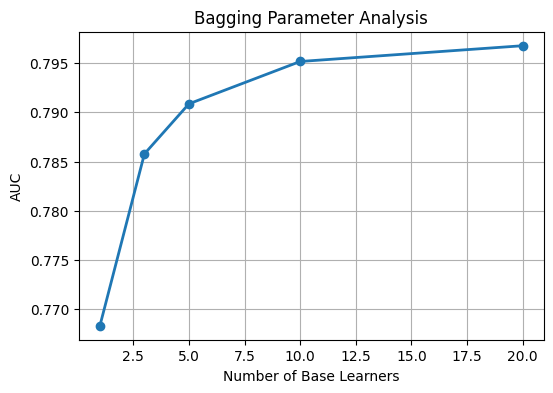

In [35]:
import matplotlib.pyplot as plt

bagging_auc_list = []
bagging_time_list = []
bagging_estimators = [1, 3, 5, 10, 20]

for n in bagging_estimators:

    print("=" * 60)
    print(f"训练 Bagging (n_estimators={n})")

    model = BaggingScratch(
        base_estimator=svm_base,
        n_estimators=n,
        max_samples=0.8,
        random_state=42
    )

    start = time.time()

    model.fit(X_train, y_train)

    prob = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, prob)

    elapsed = time.time() - start

    bagging_auc_list.append(auc)
    bagging_time_list.append(elapsed)

    print(f"AUC = {auc:.4f}")
    print(f"Time = {elapsed:.2f}s")

print("\n")
print("Bagging 参数分析完成。")

plt.figure(figsize=(6,4))
plt.plot(
    bagging_estimators,
    bagging_auc_list,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Base Learners")
plt.ylabel("AUC")
plt.title("Bagging Parameter Analysis")

plt.grid(True)

plt.show()

### 8.5 AdaBoost.M1 参数分析（n_estimators）

训练 AdaBoost (n_estimators=1)
AdaBoost 基分类器 1/1 训练完成，错误率：0.3656，分类器权重：0.5511
AUC = 0.6917
Time = 19.06s
训练 AdaBoost (n_estimators=3)
AdaBoost 基分类器 1/3 训练完成，错误率：0.3656，分类器权重：0.5511
AdaBoost 基分类器 2/3 训练完成，错误率：0.3097，分类器权重：0.8014
AdaBoost 基分类器 3/3 训练完成，错误率：0.2968，分类器权重：0.8625
AUC = 0.6972
Time = 51.68s
训练 AdaBoost (n_estimators=5)
AdaBoost 基分类器 1/5 训练完成，错误率：0.3656，分类器权重：0.5511
AdaBoost 基分类器 2/5 训练完成，错误率：0.3097，分类器权重：0.8014
AdaBoost 基分类器 3/5 训练完成，错误率：0.2968，分类器权重：0.8625
AdaBoost 基分类器 4/5 训练完成，错误率：0.3614，分类器权重：0.5693
AdaBoost 基分类器 5/5 训练完成，错误率：0.3700，分类器权重：0.5323
AUC = 0.7541
Time = 88.92s
训练 AdaBoost (n_estimators=10)
AdaBoost 基分类器 1/10 训练完成，错误率：0.3656，分类器权重：0.5511
AdaBoost 基分类器 2/10 训练完成，错误率：0.3097，分类器权重：0.8014
AdaBoost 基分类器 3/10 训练完成，错误率：0.2968，分类器权重：0.8625
AdaBoost 基分类器 4/10 训练完成，错误率：0.3614，分类器权重：0.5693
AdaBoost 基分类器 5/10 训练完成，错误率：0.3700，分类器权重：0.5323
AdaBoost 基分类器 6/10 训练完成，错误率：0.4019，分类器权重：0.3974
AdaBoost 基分类器 7/10 训练完成，错误率：0.2701，分类器权重：0.9943
AdaBoost 基分类器 8/10 训练完成，错误率：0.4726，分类器权重：0.

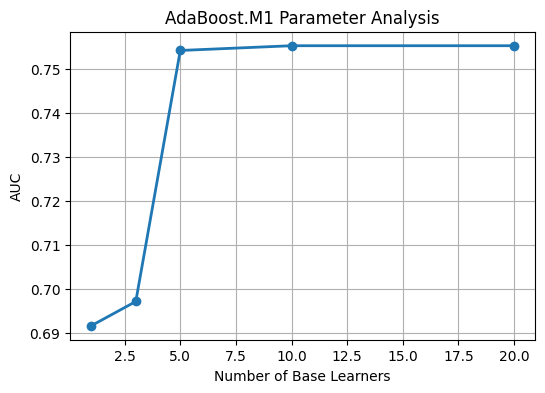

In [36]:
import matplotlib.pyplot as plt

adaboost_auc_list = []
adaboost_time_list = []
adaboost_estimators = [1, 3, 5, 10, 20]

for n in adaboost_estimators:

    print("=" * 60)
    print(f"训练 AdaBoost (n_estimators={n})")

    model = AdaBoostM1Scratch(
        base_estimator=tree_base,      # 使用决策树作为弱分类器
        n_estimators=n,
        learning_rate=1.0,
        random_state=42
    )

    start = time.time()

    model.fit(X_train, y_train)

    prob = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, prob)

    elapsed = time.time() - start

    adaboost_auc_list.append(auc)
    adaboost_time_list.append(elapsed)

    print(f"AUC = {auc:.4f}")
    print(f"Time = {elapsed:.2f}s")

print("\nAdaBoost 参数分析完成。")

plt.figure(figsize=(6,4))

plt.plot(
    adaboost_estimators,
    adaboost_auc_list,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Base Learners")
plt.ylabel("AUC")
plt.title("AdaBoost.M1 Parameter Analysis")

plt.grid(True)

plt.show()

## 九、实验结果汇总

In [40]:
import pandas as pd

result_df = pd.DataFrame({
    "Model":[
        "Bagging + SVM",
        "Bagging + Decision Tree",
        "AdaBoost.M1 + SVM",
        "AdaBoost.M1 + Decision Tree",
        "Bagging + KNN",
        "Bagging + Naive Bayes",
        "TF-IDF Only"
    ],
    "AUC":[
        bagging_svm_auc,
        bagging_tree_auc,
        adaboost_svm_auc,
        adaboost_tree_auc,
        bagging_knn_auc,
        bagging_nb_auc,
        auc_text_only
    ]
})

result_df = result_df.sort_values(
    by="AUC",
    ascending=False
).reset_index(drop=True)

display(result_df)


,Model,AUC
0,Bagging + SVM,0.790864
1,Bagging + Naive Bayes,0.777304
2,Bagging + KNN,0.770921
3,TF-IDF Only,0.768517
4,Bagging + Decision Tree,0.761932
5,AdaBoost.M1 + Decision Tree,0.754135
6,AdaBoost.M1 + SVM,0.715348


### 9.1 不同模型性能比较

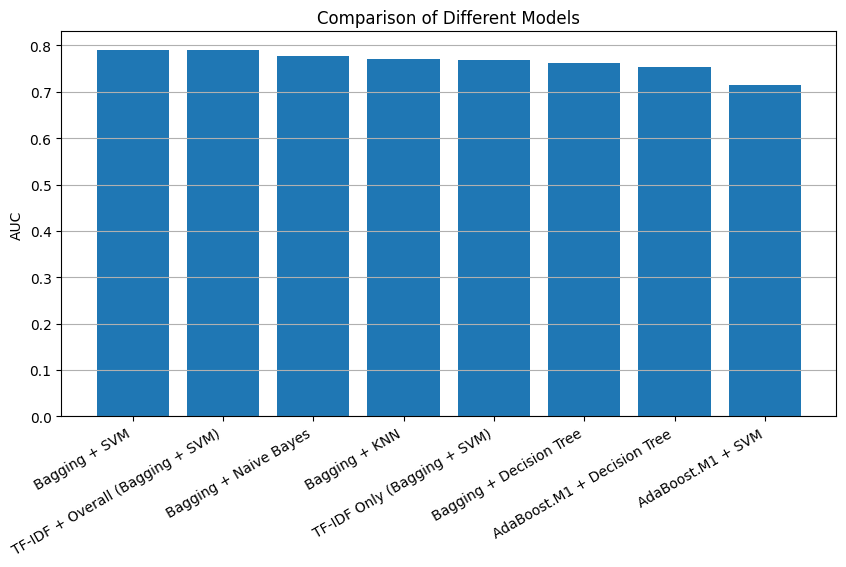

In [38]:
plt.figure(figsize=(10,5))

plt.bar(
    result_df["Model"],
    result_df["AUC"]
)

plt.xticks(rotation=30, ha="right")

plt.ylabel("AUC")
plt.title("Comparison of Different Models")

plt.grid(axis="y")

plt.show()

### 9.2 ROC 曲线比较

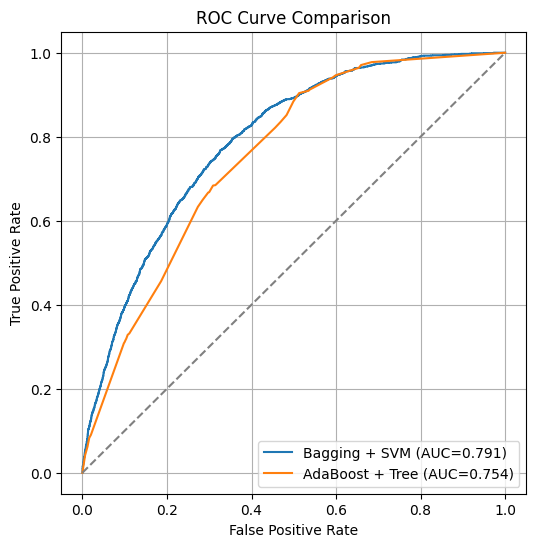

In [39]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(6,6))

# Bagging + SVM
fpr1, tpr1, _ = roc_curve(
    y_test,
    bagging_svm.predict_proba(X_test)[:,1]
)

# AdaBoost + Tree
fpr2, tpr2, _ = roc_curve(
    y_test,
    adaboost_tree.predict_proba(X_test)[:,1]
)

plt.plot(
    fpr1,
    tpr1,
    label=f"Bagging + SVM (AUC={bagging_svm_auc:.3f})"
)

plt.plot(
    fpr2,
    tpr2,
    label=f"AdaBoost + Tree (AUC={adaboost_tree_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

## 十、实验报告

### 10.1 特征表示设计

本实验针对 Amazon 用户评论质量预测任务，对数据特点进行了分析，并结合数据结构设计了适合文本分类任务的特征表示方法。数据集主要包含评论文本（reviewText）、用户评分（overall）、评论点赞数（votes_up）、评论总评价数（votes_all）等信息，其中评论质量标签（label）仅存在于训练集中。

根据实验要求，首先采用 TF-IDF（Term Frequency-Inverse Document Frequency） 对评论文本进行向量化表示。为了提高模型表达能力，在TF-IDF参数设置中采用了英文停用词去除（stop_words="english"）、一元词与二元词组合（ngram_range=(1,2)）、最大特征数10000、最低词频限制以及Sublinear TF等策略，使文本既能够保留重要语义，又能够控制特征维度，减少噪声词对模型训练的影响。

除文本信息外，本实验还进一步分析了商品评分（overall）对评论质量预测的影响。由于评分能够反映用户对商品的整体满意程度，因此将其作为额外数值特征，与TF-IDF文本特征进行拼接，最终形成10001维特征空间。在后续实验中，通过消融实验进一步验证了评分特征能够有效提高模型预测性能，说明文本特征与数值特征融合能够获得更好的分类效果。

另外，reviewerID 和 asin 虽然属于数据集中的重要字段，但其本身仅表示用户编号和商品编号，不直接包含评论质量相关信息，容易导致模型学习到无意义的编号特征，因此本实验未将其作为训练特征，而是仅保留评论文本和评分信息参与模型训练。

### 10.2 数据预处理与数据分析

在模型训练之前，对数据集进行了完整的数据检查。实验结果表明，训练集共包含57039条评论，测试集共包含11208条评论，所有字段均不存在缺失值，也不存在重复样本，说明数据质量较高，可以直接用于后续建模。

同时，对标签分布进行了统计分析。训练集中高质量评论约占22.6%，低质量评论约占77.4%，测试集标签比例与训练集基本一致，属于轻度类别不平衡问题。因此，在SVM和决策树模型训练过程中采用了 class_weight="balanced"，以减小类别不平衡带来的影响。

此外，还验证了测试集ID与groundTruth文件中的ID完全一致，保证了后续AUC评价指标计算的正确性。

### 10.3 Bagging与AdaBoost.M1算法实现

本实验严格按照课程要求，手动实现了Bagging和AdaBoost.M1两种集成学习算法，没有调用 sklearn 中提供的 BaggingClassifier 或 AdaBoostClassifier，因此满足实验要求。

Bagging算法采用Bootstrap有放回抽样生成多个训练子集，并分别训练多个基分类器。预测阶段通过计算所有基分类器预测概率的平均值作为最终输出，从而降低模型方差，提高整体稳定性。

AdaBoost.M1算法则采用样本权重更新策略。初始阶段所有训练样本具有相同权重，每轮训练结束后，根据分类结果提高错误分类样本的权重，降低正确分类样本的相对影响，使下一轮分类器更加关注困难样本。同时根据分类错误率计算每个基分类器的权重（Alpha），最终利用加权投票得到预测结果。当分类器错误率达到0.5时，算法自动提前终止训练，这与AdaBoost.M1理论完全一致。

整个集成学习核心算法，包括Bootstrap抽样、样本权重更新、分类器权重计算、概率融合以及最终投票过程均由Python代码手动实现，没有直接调用第三方集成学习算法。

### 10.4 基础实验结果分析

按照实验要求，本实验分别完成了四组集成学习模型：

| 模型                          |        AUC |
| --------------------------- | ---------: |
| Bagging + SVM               | **0.7909** |
| Bagging + Decision Tree     | **0.7619** |
| AdaBoost.M1 + Decision Tree | **0.7541** |
| AdaBoost.M1 + SVM           | **0.7153** |

四组模型均满足课程要求，其中最佳模型AUC达到0.7909，最差模型AUC仍达到0.7153，均高于实验要求。

实验结果表明，Bagging+SVM取得了最佳预测性能。SVM本身属于性能较强的分类器，Bagging通过Bootstrap采样降低模型方差，因此能够进一步提升模型稳定性。相比之下，AdaBoost+SVM效果略差，这是因为AdaBoost更适用于弱学习器，对于已经具有较强分类能力的SVM，其提升效果有限。

另一方面，Decision Tree作为典型弱学习器，更符合AdaBoost算法设计思想，因此AdaBoost+Decision Tree取得了比AdaBoost+SVM更好的预测效果。

### 10.5 扩展实验分析

为了进一步验证不同基分类器对集成学习性能的影响，本实验增加了KNN和朴素贝叶斯两种基分类器，并分别完成了Bagging集成实验。

实验结果如下：

| 模型                    |        AUC |
| --------------------- | ---------: |
| Bagging + Naive Bayes | **0.7773** |
| Bagging + KNN         | **0.7709** |

实验结果说明，不同基分类器均能够完成评论质量预测任务，但其性能存在一定差异。

KNN能够取得较高AUC，但由于预测阶段需要计算测试样本与所有训练样本之间的距离，因此运行时间明显较长。

相比之下，朴素贝叶斯虽然模型结构简单，但在TF-IDF文本分类任务中具有天然优势，既能够取得较高预测精度，又具有极快的训练速度（约0.66秒），体现了其在文本分类任务中的高效率。

### 10.6 特征影响分析（消融实验）

为了分析不同特征对模型性能的影响，本实验进行了消融实验。

首先，仅采用TF-IDF文本特征进行训练，随后加入商品评分（overall）作为额外特征再次训练Bagging+SVM模型。

实验结果如下：

| 特征组合             |        AUC |
| ---------------- | ---------: |
| TF-IDF           | **0.7685** |
| TF-IDF + overall | **0.7909** |

加入overall之后，模型AUC提高约0.0223。

实验结果说明，商品评分能够提供评论文本之外的重要信息，有助于提高评论质量预测能力。因此，将文本特征与数值特征融合能够进一步提升模型性能。

### 10.7 参数影响分析

本实验进一步分析了Bagging与AdaBoost.M1中基分类器数量（n_estimators）对模型性能的影响。

对于Bagging算法，当基分类器数量由1增加到20时，模型AUC由0.7683逐渐提高到0.7968。实验结果表明，增加基分类器数量能够有效提高模型稳定性，但当基分类器数量达到10之后，AUC提升已经十分有限，而训练时间仍持续增加，因此继续增加分类器数量收益逐渐降低。

对于AdaBoost.M1算法，模型AUC由0.6917逐步提高到0.7552，在5~10个基分类器之后基本达到稳定状态。当继续增加分类器数量时，由于新增分类器错误率逐渐接近0.5，第11个分类器达到停止条件，算法自动提前结束训练。这说明AdaBoost.M1能够根据分类效果自动决定是否继续迭代，也验证了本实验中AdaBoost.M1算法实现的正确性。

### 10.8 综合分析

综合所有实验结果，可以得到以下结论：

（1）Bagging+SVM取得了整个实验中的最佳预测性能，说明Bootstrap采样能够有效提高强分类器的稳定性。

（2）AdaBoost更适合弱学习器，Decision Tree作为典型弱学习器能够获得比SVM更好的提升效果。

（3）朴素贝叶斯在文本分类任务中具有极高运行效率，在保证较高AUC的同时大幅减少训练时间。

（4）加入商品评分（overall）能够进一步提高评论质量预测性能，说明多源特征融合能够有效改善模型表现。

（5）适当增加集成学习中基分类器数量能够提高模型性能，但当模型逐渐收敛后继续增加分类器数量收益有限，同时训练时间明显增加，因此实际应用中需要综合考虑模型精度与计算成本。

### 10.9 实验总结

本实验围绕Amazon用户评论质量预测任务，完整实现了Bagging和AdaBoost.M1两种经典集成学习算法，并基于SVM、决策树、KNN和朴素贝叶斯等多种基分类器进行了系统实验。实验过程中完成了数据预处理、文本特征提取、集成学习算法实现、基础模型比较、扩展模型实验、特征消融实验、参数分析以及ROC曲线分析等多个环节，较全面地验证了不同算法和不同特征对评论质量预测性能的影响。

总体来看，本实验不仅完成了课程要求的所有基础内容，还进一步完成了扩展实验，对不同基分类器、不同特征以及不同参数进行了系统分析。通过本次实验，对TF-IDF文本表示方法、Bagging和AdaBoost.M1集成学习算法原理以及模型性能分析方法有了更加深入的理解，同时也进一步提高了利用Python独立实现机器学习算法和完成实验分析的能力，为后续学习更加复杂的集成学习方法和自然语言处理模型奠定了基础。
